In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from mlxtend.plotting import plot_decision_regions

In [2]:
dataset=pd.read_csv("bill_authentication.csv")
dataset.head(3)

,Variance,Skewness,Curtosis,Entropy,Class
0,3.6216,8.6661,-2.8073,-0.44699,0
1,4.5459,8.1674,-2.4586,-1.46210,0
2,3.8660,-2.6383,1.9242,0.10645,0


In [3]:
dataset.isnull().sum()

Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64

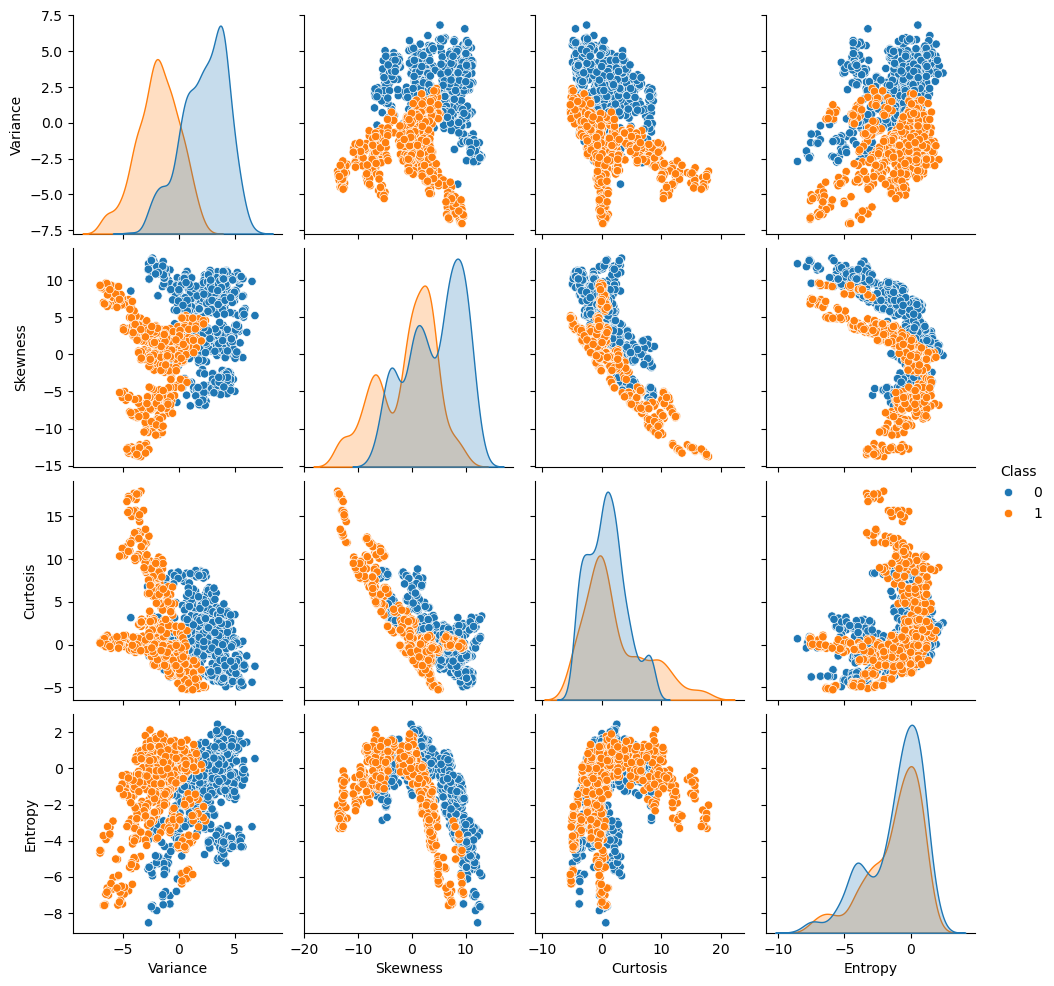

In [4]:
sns.pairplot(data=dataset,hue="Class")
plt.show()

In [5]:
x=dataset.iloc[:,:-1]
y=dataset["Class"]

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

dt=DecisionTreeClassifier() #use pruning(max_depth=8)
dt.fit(x_train,y_train)
dt.score(x_test,y_test)*100

98.18181818181819

In [24]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

df={
    "criterion":["gini", "entropy", "log_loss"],
    'splitter':["best", "random"],
    'max_depth':[i for i in range(0,10)],
}
gs=GridSearchCV(DecisionTreeClassifier(),param_grid=df)
gs.fit(x_train,y_train)
gs.best_score_

/home/78903a55-b1b9-4cbd-b726-90462af350cf/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
30 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/home/78903a55-b1b9-4cbd-b726-90462af350cf/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/78903a55-b1b9-4cbd-b726-90462af350cf/.local/lib/python3.10/site-packages/sklearn/base.py", line 1358, in wrapper
    estimator._validate_params()
  File "/home/78903a55-b1b9-4cbd-b726-90462af350cf/.local/lib/python3.10/site

0.9854130344541303